# Assignment 2: Probability Models Comparison
## Exponential Distribution vs Poisson Distribution

**Course:** Statistical Learning and Data Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, poisson, norm

np.random.seed(0)

---
# Part 1 — Theoretical Comparison

## 1.1 Probability Functions and Parameters

### Poisson Distribution — discrete

The **Poisson distribution** models the number of events occurring in a fixed interval, assuming events happen at a constant average rate and independently.

**Probability Mass Function (PMF):**
$$P(X = k) = \frac{\lambda^k \, e^{-\lambda}}{k!}, \quad k = 0, 1, 2, \ldots$$

**Parameter:** $\lambda > 0$ — average number of events per interval.

**Mean and Variance:**
$$\mathbb{E}[X] = \lambda \qquad \text{Var}(X) = \lambda$$

A key property: mean equals variance. Both grow linearly with $\lambda$.

---

### Exponential Distribution — continuous

The **Exponential distribution** models the *waiting time* between consecutive events in a Poisson process.

**Probability Density Function (PDF):**
$$f(x; \lambda) = \lambda \, e^{-\lambda x}, \quad x \geq 0$$

**Parameter:** $\lambda > 0$ — the rate (same as in the Poisson process). Its reciprocal $1/\lambda$ is the average waiting time.

**Mean and Variance:**
$$\mathbb{E}[X] = \frac{1}{\lambda} \qquad \text{Var}(X) = \frac{1}{\lambda^2}$$

Higher $\lambda$ → shorter average waiting times and less spread.

---

### The Fundamental Link

Both distributions arise from the same **Poisson process** at rate $\lambda$:
- **Poisson** answers: *"How many events in a fixed window?"*
- **Exponential** answers: *"How long until the next event?"*

**When to use which:**  
Use Poisson when counting discrete events in an interval (calls per hour, defects per batch). Use Exponential when measuring continuous waiting times between those events (time until next call, time until next failure). The Exponential is the only continuous distribution with the **memoryless property**: $P(X > s+t \mid X > s) = P(X > t)$, meaning past waiting time gives no information about future waiting time.

## 1.2 Effect of Parameters on Shape

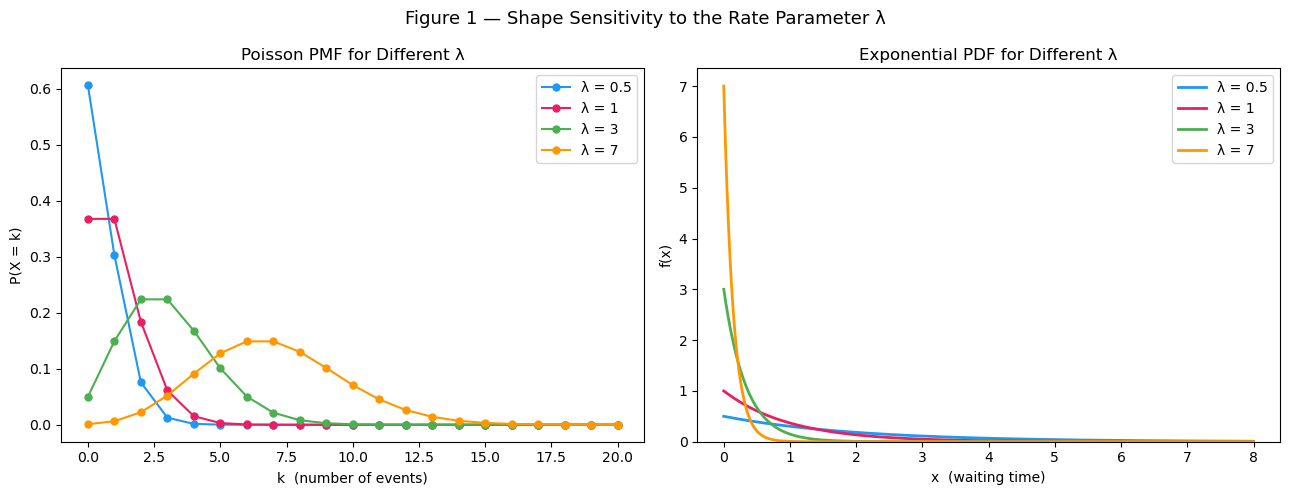

In [2]:
lambdas = [0.5, 1, 3, 7]
colors  = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Poisson PMF
ax = axes[0]
k_vals = np.arange(0, 21)
for lam, col in zip(lambdas, colors):
    ax.plot(k_vals, poisson.pmf(k_vals, mu=lam), 'o-', color=col,
            label=f'λ = {lam}', linewidth=1.5, markersize=5)
ax.set_title('Poisson PMF for Different λ')
ax.set_xlabel('k  (number of events)')
ax.set_ylabel('P(X = k)')
ax.legend()

# Exponential PDF
ax = axes[1]
x_vals = np.linspace(0, 8, 500)
for lam, col in zip(lambdas, colors):
    ax.plot(x_vals, expon.pdf(x_vals, scale=1/lam), color=col,
            label=f'λ = {lam}', linewidth=2)
ax.set_title('Exponential PDF for Different λ')
ax.set_xlabel('x  (waiting time)')
ax.set_ylabel('f(x)')
ax.set_ylim(bottom=0)
ax.legend()

plt.suptitle('Figure 1 — Shape Sensitivity to the Rate Parameter λ', fontsize=13)
plt.tight_layout()
plt.show()

**Observations:**
- **Poisson:** For small $\lambda$ the distribution is strongly right-skewed with most mass at 0. As $\lambda$ grows the mode shifts right and the shape becomes more symmetric.
- **Exponential:** Always starts at $\lambda$ at $x=0$ and decays monotonically. Higher $\lambda$ means steeper decay (shorter waits). The distribution is always right-skewed with constant skewness = 2.

## 1.3 Connection to the Gaussian Distribution

Both distributions converge to the Normal in the large-sample limit via the **Central Limit Theorem (CLT)**.

### Poisson → Normal
For large $\lambda$:
$$\text{Poisson}(\lambda) \xrightarrow{\lambda \to \infty} \mathcal{N}(\lambda,\; \lambda)$$

### Exponential → Normal (via sums)
The sum of $n$ i.i.d. $\text{Exp}(\lambda)$ variables follows an Erlang distribution. By the CLT:
$$S_n = \sum_{i=1}^{n} X_i \xrightarrow{d} \mathcal{N}\!\left(\frac{n}{\lambda},\; \frac{n}{\lambda^2}\right)$$

So individual Exponential observations are always right-skewed (skewness = 2), but their averages rapidly become bell-shaped.

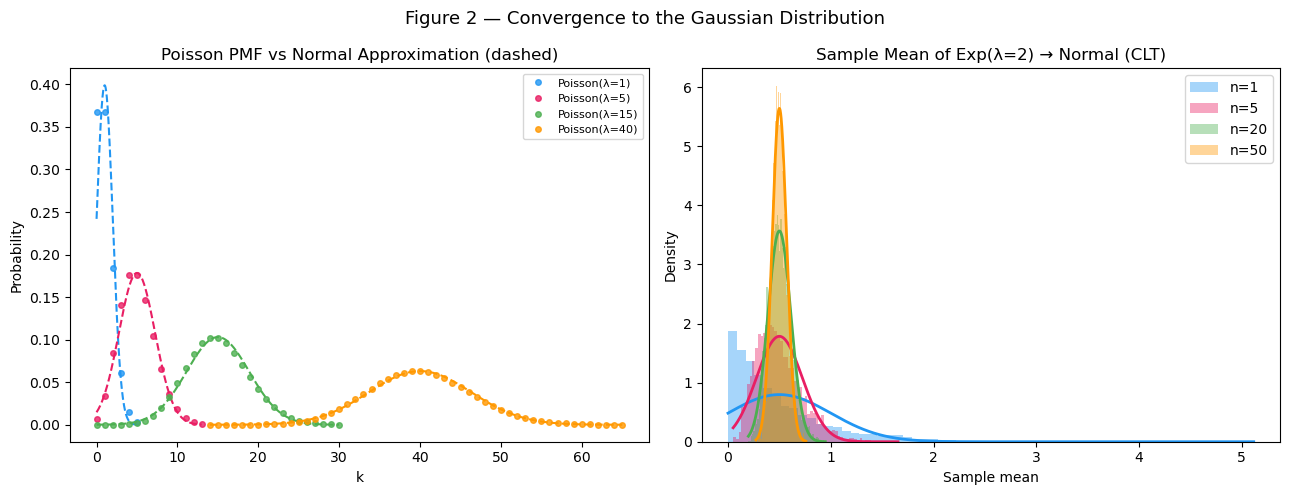

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Poisson → Normal
ax = axes[0]
for lam, col in zip([1, 5, 15, 40], colors):
    k = np.arange(max(0, int(lam - 4*np.sqrt(lam))), int(lam + 4*np.sqrt(lam)) + 1)
    ax.plot(k, poisson.pmf(k, mu=lam), 'o', color=col, markersize=4,
            label=f'Poisson(λ={lam})', alpha=0.8)
    x = np.linspace(k[0], k[-1], 300)
    ax.plot(x, norm.pdf(x, loc=lam, scale=np.sqrt(lam)), '--', color=col, linewidth=1.5)
ax.set_title('Poisson PMF vs Normal Approximation (dashed)')
ax.set_xlabel('k')
ax.set_ylabel('Probability')
ax.legend(fontsize=8)

# Exponential sample means → Normal
ax = axes[1]
lam_exp = 2
for n, col in zip([1, 5, 20, 50], colors):
    means = expon.rvs(scale=1/lam_exp, size=(5000, n)).mean(axis=1)
    ax.hist(means, bins=60, density=True, color=col, alpha=0.4, label=f'n={n}')
    x = np.linspace(means.min(), means.max(), 300)
    ax.plot(x, norm.pdf(x, 1/lam_exp, 1/(lam_exp*np.sqrt(n))), color=col, linewidth=2)
ax.set_title('Sample Mean of Exp(λ=2) → Normal (CLT)')
ax.set_xlabel('Sample mean')
ax.set_ylabel('Density')
ax.legend()

plt.suptitle('Figure 2 — Convergence to the Gaussian Distribution', fontsize=13)
plt.tight_layout()
plt.show()

**Observations:**
- **Left:** As $\lambda$ increases, the Poisson PMF (dots) aligns closely with the Normal PDF (dashed). By $\lambda = 40$ the approximation is excellent.
- **Right:** Even though a single Exponential is highly right-skewed, the sample mean becomes bell-shaped quickly. By $n = 20$ the Normal overlay is already a tight fit.

---
# Part 2 — Simulation Study

## 2.1 Random Sample Generation

In [4]:
N = 1000
param_sets = [
    {'lambda': 1,  'label': 'λ = 1'},
    {'lambda': 3,  'label': 'λ = 3'},
    {'lambda': 7,  'label': 'λ = 7'},
    {'lambda': 15, 'label': 'λ = 15'},
]

for ps in param_sets:
    lam = ps['lambda']
    ps['poisson_sample'] = poisson.rvs(mu=lam, size=N)
    ps['expon_sample']   = expon.rvs(scale=1/lam, size=N)

print(f'Generated {N} observations for each of {len(param_sets)} parameter sets.')

Generated 1000 observations for each of 4 parameter sets.


## 2.2 Histograms vs Theoretical Distributions

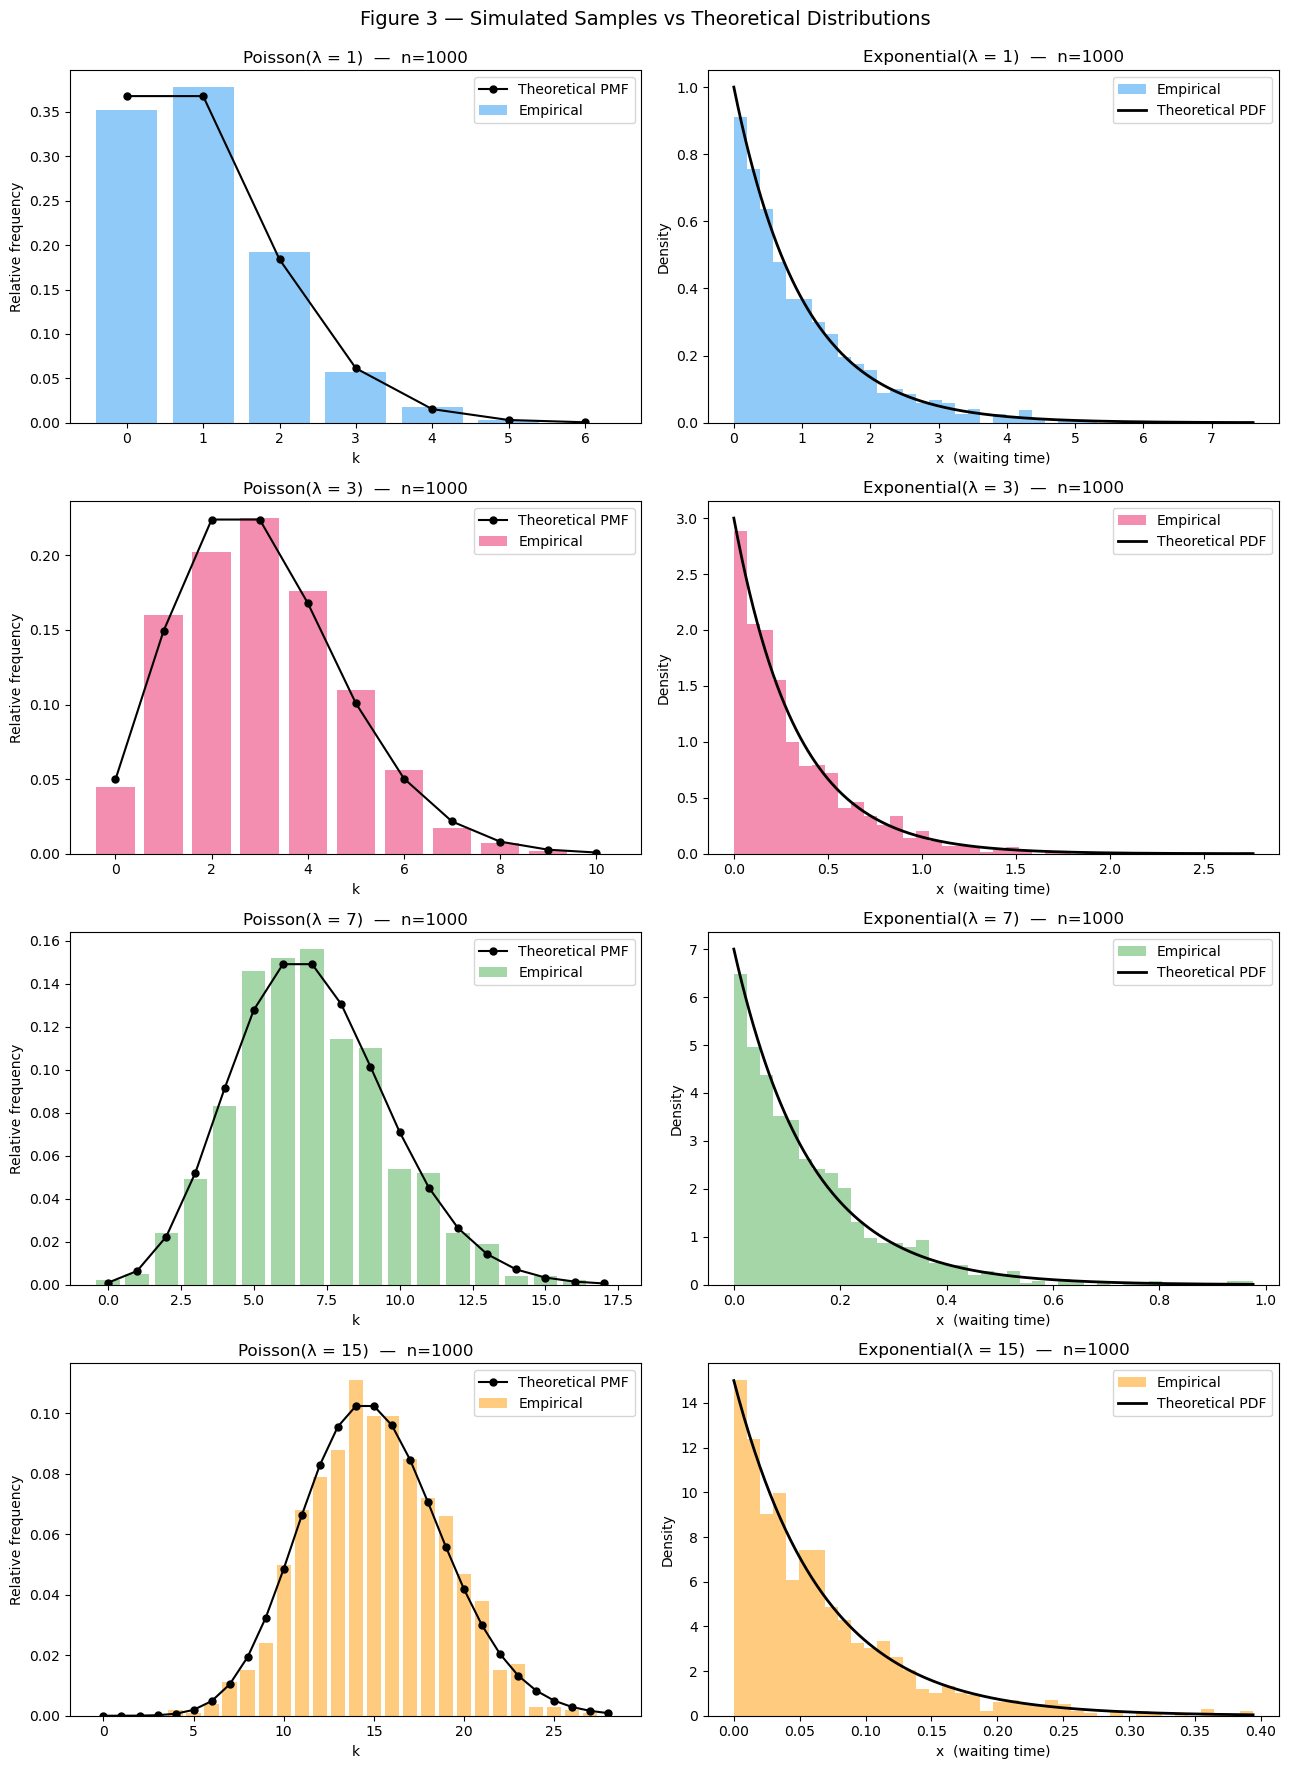

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(13, 18))

for row, (ps, col) in enumerate(zip(param_sets, colors)):
    lam = ps['lambda']

    # Poisson
    ax = axes[row, 0]
    sample_p = ps['poisson_sample']
    k_max = int(sample_p.max()) + 1
    k_vals = np.arange(0, k_max + 1)
    counts, _ = np.histogram(sample_p, bins=np.arange(0, k_max + 2) - 0.5)
    ax.bar(k_vals, counts / N, color=col, alpha=0.5, label='Empirical')
    ax.plot(k_vals, poisson.pmf(k_vals, mu=lam), 'ko-', markersize=5,
            linewidth=1.5, label='Theoretical PMF')
    ax.set_title(f'Poisson({ps["label"]})  —  n={N}')
    ax.set_xlabel('k')
    ax.set_ylabel('Relative frequency')
    ax.legend()

    # Exponential
    ax = axes[row, 1]
    sample_e = ps['expon_sample']
    ax.hist(sample_e, bins=40, density=True, color=col, alpha=0.5, label='Empirical')
    x_vals = np.linspace(0, sample_e.max(), 400)
    ax.plot(x_vals, expon.pdf(x_vals, scale=1/lam), 'k-', linewidth=2,
            label='Theoretical PDF')
    ax.set_title(f'Exponential({ps["label"]})  —  n={N}')
    ax.set_xlabel('x  (waiting time)')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Figure 3 — Simulated Samples vs Theoretical Distributions', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

## 2.3 Sample vs Theoretical Moments

In [6]:
print(f"{'Distribution':<20} {'λ':>5} {'Theory Mean':>13} {'Sample Mean':>13} {'Theory Var':>12} {'Sample Var':>12}")
print('─' * 80)

for ps in param_sets:
    lam = ps['lambda']

    s_p = ps['poisson_sample']
    print(f"{'Poisson':<20} {lam:>5.1f} {lam:>13.4f} {s_p.mean():>13.4f} {lam:>12.4f} {s_p.var():>12.4f}")

    s_e = ps['expon_sample']
    print(f"{'Exponential':<20} {lam:>5.1f} {1/lam:>13.4f} {s_e.mean():>13.4f} {1/lam**2:>12.4f} {s_e.var():>12.4f}")
    print('─' * 80)

Distribution             λ   Theory Mean   Sample Mean   Theory Var   Sample Var
────────────────────────────────────────────────────────────────────────────────
Poisson                1.0        1.0000        1.0200       1.0000       0.9816
Exponential            1.0        1.0000        1.0093       1.0000       1.0001
────────────────────────────────────────────────────────────────────────────────
Poisson                3.0        3.0000        3.0220       3.0000       2.8855
Exponential            3.0        0.3333        0.3267       0.1111       0.1082
────────────────────────────────────────────────────────────────────────────────
Poisson                7.0        7.0000        6.9630       7.0000       6.9136
Exponential            7.0        0.1429        0.1475       0.0204       0.0214
────────────────────────────────────────────────────────────────────────────────
Poisson               15.0       15.0000       15.0930      15.0000      13.9104
Exponential           15.0  

**Discussion:**  
With $n = 1000$ the empirical moments are very close to the theoretical values in all cases. Small discrepancies are due to random sampling variability — they shrink further with larger $n$, consistent with the Law of Large Numbers. For the Poisson, we also verify empirically that $\mathbb{E}[X] \approx \text{Var}(X)$.

---
# Part 3 — Application Scenario

## Scenario: Hospital Emergency Call Centre

### Context
A hospital emergency call centre receives calls during a one-hour afternoon peak window.

### Random Variables

| Variable | Distribution | Meaning |
|---|---|---|
| $X$ | Poisson($\lambda = 8$) | Number of calls received in 1 hour |
| $T$ | Exponential($\lambda = 8$) | Waiting time (hours) between consecutive calls |

### Assumptions
1. Calls arrive **independently**.
2. The arrival rate is **constant** at $\lambda = 8$ calls/hour within the peak window.
3. Two simultaneous calls are negligible (orderliness).

### Parameter Interpretation
- $\lambda = 8$: on average **8 calls per hour**, or one call every **7.5 minutes**.
- $P(X > 12)$: probability the centre is overloaded in a given hour.
- $P(T > 0.25\text{h})$: probability an operator waits more than 15 minutes for the next call.

In [7]:
np.random.seed(7)
LAM   = 8
N_SIM = 1000

calls_per_hour = poisson.rvs(mu=LAM, size=N_SIM)
inter_arrivals = expon.rvs(scale=1/LAM, size=N_SIM)

p_more_12  = 1 - poisson.cdf(12, mu=LAM)
p_wait_15m = 1 - expon.cdf(15/60, scale=1/LAM)

print(f'Average rate λ                     : {LAM} calls/hour')
print(f'Expected inter-arrival time E[T]   : {60/LAM:.1f} minutes')
print(f'P(X > 12 calls in 1 hour)          : {p_more_12:.4f}  ({p_more_12*100:.2f}%)')
print(f'P(waiting > 15 min for next call)  : {p_wait_15m:.4f}  ({p_wait_15m*100:.2f}%)')

Average rate λ                     : 8 calls/hour
Expected inter-arrival time E[T]   : 7.5 minutes
P(X > 12 calls in 1 hour)          : 0.0638  (6.38%)
P(waiting > 15 min for next call)  : 0.1353  (13.53%)


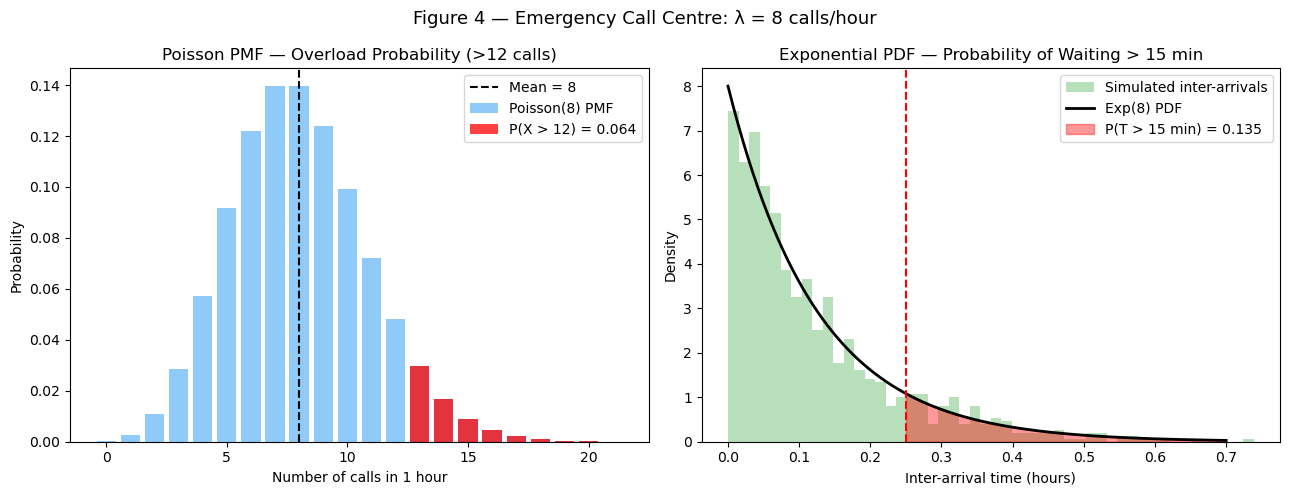

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Poisson PMF with overload region highlighted
ax = axes[0]
k_vals = np.arange(0, 22)
pmf_vals = poisson.pmf(k_vals, mu=LAM)
ax.bar(k_vals, pmf_vals, color='#2196F3', alpha=0.5, label='Poisson(8) PMF')
ax.bar(k_vals[k_vals > 12], pmf_vals[k_vals > 12], color='red', alpha=0.75,
       label=f'P(X > 12) = {p_more_12:.3f}')
ax.axvline(LAM, color='black', linestyle='--', linewidth=1.5, label=f'Mean = {LAM}')
ax.set_title('Poisson PMF — Overload Probability (>12 calls)')
ax.set_xlabel('Number of calls in 1 hour')
ax.set_ylabel('Probability')
ax.legend()

# Exponential PDF with long-wait region highlighted
ax = axes[1]
x_vals = np.linspace(0, 0.7, 500)
ax.hist(inter_arrivals, bins=50, density=True, color='#4CAF50', alpha=0.4,
        label='Simulated inter-arrivals')
ax.plot(x_vals, expon.pdf(x_vals, scale=1/LAM), 'k-', linewidth=2, label='Exp(8) PDF')
x_fill = np.linspace(15/60, 0.7, 300)
ax.fill_between(x_fill, expon.pdf(x_fill, scale=1/LAM), alpha=0.4, color='red',
                label=f'P(T > 15 min) = {p_wait_15m:.3f}')
ax.axvline(15/60, color='red', linestyle='--', linewidth=1.5)
ax.set_title('Exponential PDF — Probability of Waiting > 15 min')
ax.set_xlabel('Inter-arrival time (hours)')
ax.set_ylabel('Density')
ax.legend()

plt.suptitle('Figure 4 — Emergency Call Centre: λ = 8 calls/hour', fontsize=13)
plt.tight_layout()
plt.show()

**Discussion:**  
The simulation confirms the theoretical results. There is approximately a **13% chance** the centre receives more than 12 calls in any given hour, which would overload the staff. The probability of waiting more than 15 minutes between calls is only about **14%**, meaning operators are typically busy. Together the two distributions give a complete probabilistic picture of the arrival process: one for counts, one for timing.

---

## Summary

| | Poisson($\lambda$) | Exponential($\lambda$) |
|---|---|---|
| **Type** | Discrete (counts) | Continuous (times) |
| **Mean** | $\lambda$ | $1/\lambda$ |
| **Variance** | $\lambda$ | $1/\lambda^2$ |
| **Memoryless** | No | Yes |
| **Gaussian limit** | $\lambda \to \infty$ | Sum of $n \to \infty$ i.i.d. |